In [7]:
from ase.io import read
import numpy as np
from dscribe.descriptors import SOAP
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
# from mace.calculators import MACECalculator
import os 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

train_configs_folder = 'training_configurations'
cand_configs_folder = 'candidate_configurations'
low_std_configs = 'low_std_configuration'


train_configs = [f'{train_configs_folder}/{file}' for file in os.listdir(train_configs_folder) if file.endswith('.in')]
cand_configs = [f'{cand_configs_folder}/{file}' for file in os.listdir(cand_configs_folder) if file.endswith('.in')]
low_std_configs = [f'{low_std_configs}/{file}' for file in os.listdir(low_std_configs) if file.endswith('.in')]

print(train_configs)
print(cand_configs)
print(low_std_configs)

descs = []
labels = []

['training_configurations/geometry.in', 'training_configurations/geometry (2).in', 'training_configurations/geometry (3).in', 'training_configurations/geometry (4).in', 'training_configurations/geometry (5).in', 'training_configurations/geometry (6).in', 'training_configurations/geometry (7).in', 'training_configurations/geometry (8).in', 'training_configurations/geometry (9).in', 'training_configurations/geometry (10).in', 'training_configurations/geometry (11).in', 'training_configurations/geometry (12).in', 'training_configurations/geometry (13).in', 'training_configurations/geometry (14).in', 'training_configurations/geometry (15).in', 'training_configurations/geometry (16).in', 'training_configurations/geometry (17).in', 'training_configurations/geometry (18).in', 'training_configurations/geometry (19).in', 'training_configurations/geometry_atop.in', 'training_configurations/geometry_bridge_1.in', 'training_configurations/geometry_bridge_1_high_coverage.in', 'training_configuratio

(1898, 952)
(1898,)
Performing t-SNE for initial data visualization...
(417, 952)
(417,)
Performing t-SNE for initial data visualization...
(563, 952)
(563,)
Performing t-SNE for initial data visualization...


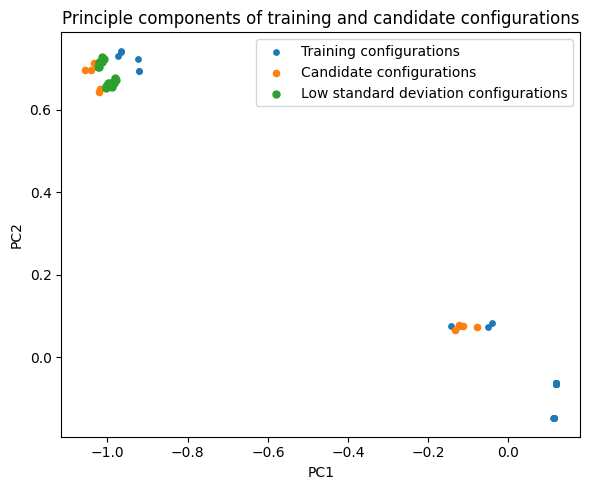

In [10]:
plt.figure(figsize=(6, 5))
pca = PCA(n_components=2, whiten=True)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1, init='pca')
plot_labels = ['Training configurations', 'Candidate configurations', 'Low standard deviation configurations']
s_list = [15,20,25]
for ind, config_list in enumerate([train_configs, cand_configs, low_std_configs]):
    
    descs = []
    labels = []
    
    for i, conf in enumerate(config_list):
        conf_atoms = read(conf)
        species = ['Co', 'H'] # Example
        soap = SOAP(species=species, periodic=False, r_cut=5.0, n_max=8, l_max=6, average='off')
        d = soap.create(conf_atoms)
        # d = StandardScaler().fit_transform(soap_descriptors)
        # d = calculator.get_descriptors(conf_atoms)
        # print(d.shape)
        descs.append(d)
        labels.extend([i] * len(d))
    
    descs = np.vstack(descs)
    labels = np.array(labels)
    
    print(descs.shape)
    print(labels.shape)
    
    
    
    print("Performing t-SNE for initial data visualization...")
    
    if config_list==train_configs:
        descs_tsne = pca.fit_transform(descs)
    else:
        descs_tsne = pca.transform(descs)
    # pca = PCA(n_components=2, whiten=True)
    # descs_pca = pca.fit_transform(descs)
    
    # print("Explained variance:", pca.explained_variance_ratio_)
    
    configs_pc1 = []
    configs_pc2 = []
    
    for i in np.unique(labels):
        mask = labels == i
        configs_pc1.append(np.mean(descs_tsne[mask, 0]))
        configs_pc2.append(np.mean(descs_tsne[mask, 1]))
    plt.scatter(configs_pc1, configs_pc2, s=s_list[ind],label=f'{plot_labels[ind]}')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.title('Principle components of training and candidate configurations')
plt.tight_layout()
# plt.savefig('tSNE analysis - SOAP with low std configurations.jpg', dpi=300)
plt.show()


In [21]:
def mahalanobis_distance(desc, mu, cov_inv):
    diff = desc - mu
    return np.sqrt(np.sum(diff @ cov_inv * diff, axis=1))

In [23]:
from sklearn.covariance import EmpiricalCovariance

for ind, config_list in enumerate([train_configs]):
    
    descs = []
    labels = []
    
    for i, conf in enumerate(config_list):
        conf_atoms = read(conf)
        species = ['Co', 'H'] # Example
        soap = SOAP(species=species, periodic=False, r_cut=5.0, n_max=8, l_max=6, average='off')
        d = soap.create(conf_atoms)
        # d = StandardScaler().fit_transform(soap_descriptors)
        # d = calculator.get_descriptors(conf_atoms)
        # print(d.shape)
        descs.append(d)
        labels.extend([i] * len(d))
    descs = np.vstack(descs)
    labels = np.array(labels)
    
    print(descs.shape)
    print(labels.shape)
    cov_model = EmpiricalCovariance()
    cov_model.fit(descs)
    
    mu = cov_model.location_
    cov_inv = cov_model.precision_

(1898, 952)
(1898,)


(1898, 952)
(1898,)
mean distance: 13.541908701029989
mean distance: 13.055960943071785
mean distance: 12.723504720694619
mean distance: 12.619646313299647
mean distance: 12.913539389886108
mean distance: 12.54820154097547
mean distance: 12.821062288692605
mean distance: 12.894823838612906
mean distance: 13.27685342211214
mean distance: 13.170584767803286
mean distance: 13.436210522859993
mean distance: 14.07013113011521
mean distance: 13.055960943071785
mean distance: 12.723504720694619
mean distance: 12.619646313299647
mean distance: 12.913539389886108
mean distance: 12.54820154097547
mean distance: 12.821062288692605
mean distance: 12.894823838612906
mean distance: 20.714283243450684
mean distance: 17.733438879902106
mean distance: 22.00095961254048
mean distance: 18.491735375196228
mean distance: 23.605446991836004
mean distance: 15.776528635120874
mean distance: 16.745158238668978
mean distance: 17.540268129680364
mean distance: 18.87033799517257
mean distance: 20.06880192641057
(

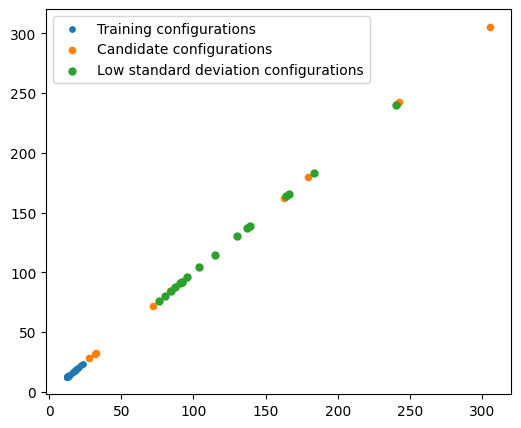

In [35]:
plt.figure(figsize=(6, 5))
for ind, config_list in enumerate([train_configs, cand_configs, low_std_configs]):
    
    descs = []
    labels = []
    
    for i, conf in enumerate(config_list):
        conf_atoms = read(conf)
        species = ['Co', 'H'] # Example
        soap = SOAP(species=species, periodic=False, r_cut=5.0, n_max=8, l_max=6, average='off')
        d = soap.create(conf_atoms)
        # d = StandardScaler().fit_transform(soap_descriptors)
        # d = calculator.get_descriptors(conf_atoms)
        # print(d.shape)
        descs.append(d)
        labels.extend([i] * len(d))
    descs = np.vstack(descs)
    labels = np.array(labels)
    
    print(descs.shape)
    print(labels.shape)

    mean_distance_list = []
    for i in np.unique(labels):
        mask = labels == i
        
        d = mahalanobis_distance(descs[mask, :], mu, cov_inv)
        mean_distance_list.append(d.mean())
        print("mean distance:", d.mean())
        # print("max distance:", d.max())
    plt.scatter(mean_distance_list,mean_distance_list, s=s_list[ind],label=f'{plot_labels[ind]}')
plt.legend()
plt.show()